---
title: Load Trained Models in PyTorch
author: Kunlei Lian
date: 06/14/2024
draft: false
categories:
  - PyTorch
  - Deep Learning
jupyter: 'blog'
format:
  html:
    code-line-numbers: true
    code-overflow: wrap
    code-block-bg: true
    code-block-border-left: true
    highlight-style: Arrow
---

## Introduction

In this blog post, we'll explore how to load pre-trained PyTorch models and use them for inference on new images. Pre-trained models are neural networks that have already been trained on large datasets (like ImageNet) and can be used for various computer vision tasks without having to train from scratch.

We'll walk through the complete process:
1. Loading a pre-trained model from torchvision
2. Preprocessing an input image
3. Running inference to get predictions
4. Interpreting the results

Let's start by checking our PyTorch version and exploring available models.


In [1]:
import torch

torch.__version__

'2.8.0'

## Step 1: Loading Pre-trained Models

PyTorch's `torchvision` library provides access to many pre-trained models. Let's first see what models are available, then load a ResNet-101 model that was pre-trained on ImageNet.


In [2]:
from torchvision import models

dir(models)

['AlexNet',
 'AlexNet_Weights',
 'ConvNeXt',
 'ConvNeXt_Base_Weights',
 'ConvNeXt_Large_Weights',
 'ConvNeXt_Small_Weights',
 'ConvNeXt_Tiny_Weights',
 'DenseNet',
 'DenseNet121_Weights',
 'DenseNet161_Weights',
 'DenseNet169_Weights',
 'DenseNet201_Weights',
 'EfficientNet',
 'EfficientNet_B0_Weights',
 'EfficientNet_B1_Weights',
 'EfficientNet_B2_Weights',
 'EfficientNet_B3_Weights',
 'EfficientNet_B4_Weights',
 'EfficientNet_B5_Weights',
 'EfficientNet_B6_Weights',
 'EfficientNet_B7_Weights',
 'EfficientNet_V2_L_Weights',
 'EfficientNet_V2_M_Weights',
 'EfficientNet_V2_S_Weights',
 'GoogLeNet',
 'GoogLeNetOutputs',
 'GoogLeNet_Weights',
 'Inception3',
 'InceptionOutputs',
 'Inception_V3_Weights',
 'MNASNet',
 'MNASNet0_5_Weights',
 'MNASNet0_75_Weights',
 'MNASNet1_0_Weights',
 'MNASNet1_3_Weights',
 'MaxVit',
 'MaxVit_T_Weights',
 'MobileNetV2',
 'MobileNetV3',
 'MobileNet_V2_Weights',
 'MobileNet_V3_Large_Weights',
 'MobileNet_V3_Small_Weights',
 'RegNet',
 'RegNet_X_16GF_Weights'

In [3]:
alexnet = models.AlexNet()

## Step 2: Image Preprocessing

Before we can use our model for inference, we need to preprocess the input image. Pre-trained models expect images in a specific format:

- **Resize and crop**: Images should be 224x224 pixels
- **Convert to tensor**: Transform from PIL Image to PyTorch tensor
- **Normalize**: Apply the same normalization that was used during training (ImageNet statistics)

The normalization values (mean and std) are specific to ImageNet and help the model perform better.


In [4]:
alexnet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [5]:
resnet = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)

Let's load our dog image and apply the preprocessing transformations:


In [6]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
from PIL import Image

# image = Image.open("./tree.jpg")
image = Image.open("./dog.jpg")

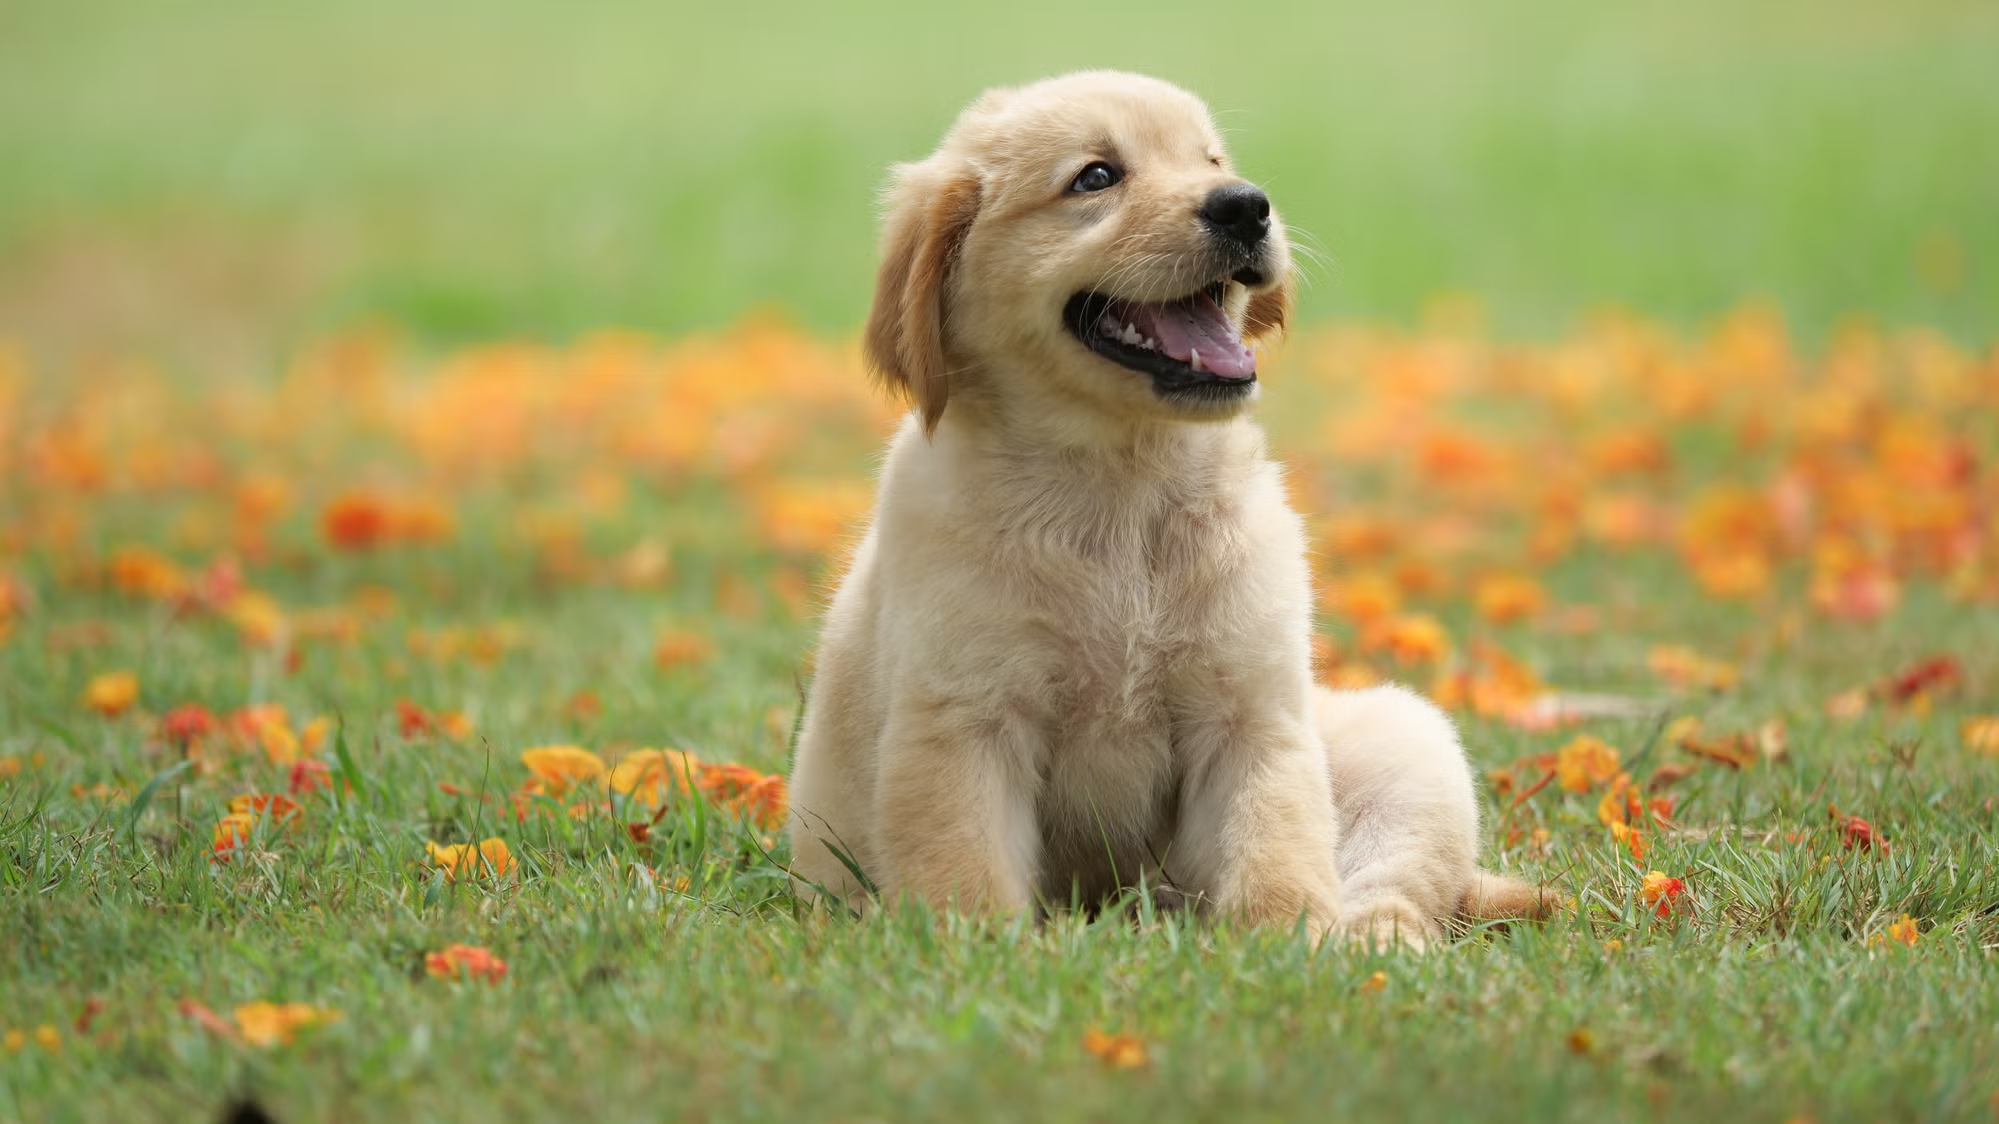

In [8]:
image

## Step 3: Model Inference

Now we're ready to run inference! Here's what we need to do:

1. **Set model to evaluation mode**: This disables dropout and batch normalization updates
2. **Add batch dimension**: Models expect batched inputs, so we add a dimension
3. **Run inference**: Use `torch.inference_mode()` for efficiency and to disable gradient computation
4. **Get predictions**: The model outputs raw logits (unnormalized scores) for each class


In [9]:
image_transformed = transform(image)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.3785625].


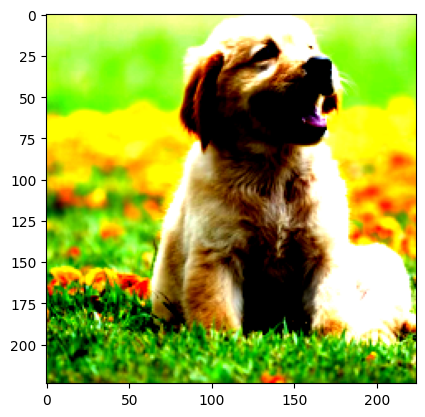

In [11]:
import matplotlib.pyplot as plt 

plt.imshow(image_transformed.permute(1, 2, 0))

In [12]:
image_batch = image_transformed.unsqueeze(dim=0)
image_batch.shape

torch.Size([1, 3, 224, 224])

In [13]:
resnet.eval()

with torch.inference_mode():
    pred_logits = resnet(image_batch)

pred_logits.shape

torch.Size([1, 1000])

## Step 4: Interpreting Results

The model outputs raw logits (scores) for each of the 1000 ImageNet classes. To make sense of these predictions, we need to:

1. **Load class labels**: Get the human-readable names for each class
2. **Convert to probabilities**: Apply softmax to get probabilities that sum to 1
3. **Find top predictions**: Sort by probability to see the most likely classes

Let's see what our model thinks the dog image contains!


In [14]:
with open("./imagenet_classes.txt") as f:
    labels = [line.strip() for line in f.readlines()] 

In [15]:
_, index = torch.max(pred_logits, dim=1)
softmax = torch.nn.Softmax(dim=1)
pred_probs = softmax(pred_logits)

In [16]:
_, indices = torch.sort(pred_logits, descending=True)
[(labels[idx], pred_logits[0][idx].item()) for idx in indices[0][:5]]

[('golden retriever', 8.721056938171387),
 ('Labrador retriever', 5.845145225524902),
 ('Brittany spaniel', 5.5844011306762695),
 ('clumber, clumber spaniel', 2.9428038597106934),
 ('Sussex spaniel', 2.8260412216186523)]

In [17]:
_, indices = torch.sort(pred_probs, descending=True)
[(labels[idx], pred_probs[0][idx].item()) for idx in indices[0][:5]]

[('golden retriever', 0.7772852182388306),
 ('Labrador retriever', 0.04381147027015686),
 ('Brittany spaniel', 0.03375577926635742),
 ('clumber, clumber spaniel', 0.0024050103966146708),
 ('Sussex spaniel', 0.0021399694960564375)]

## Summary

In this tutorial, we've successfully:

1. **Loaded a pre-trained ResNet-101 model** from torchvision
2. **Preprocessed a dog image** with the correct transformations
3. **Ran inference** to get predictions from the model
4. **Interpreted the results** by converting logits to probabilities and finding the top predictions

The model correctly identified the image as containing a dog breed, demonstrating how pre-trained models can be used for image classification without any additional training. This approach is particularly useful when you have limited data or computational resources, as you can leverage models that have already learned rich visual features from large datasets like ImageNet.

### Key Takeaways:
- Pre-trained models save time and computational resources
- Proper preprocessing is crucial for good results
- Models output raw logits that need to be converted to probabilities
- The `torch.inference_mode()` context manager is more efficient than `torch.no_grad()` for inference

You can now use this same process with any pre-trained model from torchvision for your own image classification tasks!
